# Frequency and Keyness

<a target="_blank" href="https://colab.research.google.com/github/zentralbibliothek-zuerich/zblab-summerschool-2026/blob/main/notebooks/03_frequency_and_keyness.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook contains boilerplate code that you don't need to interact with directly.

The sections where you can safely experiment or customize are clearly marked with such comments:

```python
# ⬇️⬇️⬇️
YOUR_INPUT = ""
# ⬆️⬆️⬆️

## Setup

### Housekeeping (no interaction required)

In [1]:
%pip install simplemma
%pip install nltk

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


❗ Please restart the kernel/runtime after installing the package to ensure that all changes take effect.

(Google Colab might initiate a restart on its own)

In [ ]:
import os
from pathlib import Path
from typing import Literal, Dict

import nltk
import pandas as pd
import simplemma
from tqdm import tqdm

tqdm.pandas()
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to /home/bode-
[nltk_data]     wsl/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/bode-
[nltk_data]     wsl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBLabSummerSchool2026/data') if IN_COLAB else Path('../data')

In [6]:
def confirm(question: str = "Do you want to execute this cell?"):
    while True:
        response = input(f"{question} (y/n): ").lower()
        if response in ["y", "yes"]:
            return True
        elif response in ["n", "no"]:
            return False
        else:
            print("Please enter 'y' or 'n'.")

### Setup (Interaction required)

In [ ]:
### ⬇️⬇️⬇️  Adjust here if you want to continue with your own query
CORPUS_NAME = "armenpflege"
USE_YOUR_DATA = False
### ⬆️⬆️⬆️

In [8]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

## Load the data


### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [ ]:
if USE_YOUR_DATA:
    RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.parquet"
    raw_df = pd.read_parquet(RAWDATA_PATH)

### <img src="https://www.zb.uzh.ch/themes/zb/assets/images/favicon-192.png" alt="💾" width=16> Load from Github

In [ ]:
if not USE_YOUR_DATA:
    print("Loading data from GitHub...", end=" ")
    RAWDATA_URL = "https://media.githubusercontent.com/media/zentralbibliothek-zuerich/zblab-summerschool-2026/main/data/armenpflege.filtered.parquet"
    raw_df = pd.read_parquet(RAWDATA_URL)
    print("Done!")

Loading data from GitHub... Done!


### Parsing and preparing

For easier handling, the cell below extracts only the year from the complex date column.

`1880-03-07T00:00:00+00:00` ➡️ `1880`

In [47]:
raw_df["year"] = pd.to_datetime(raw_df["date"]).dt.year

## Preprocess Corpus

At the moment, the corpus only consists metadate and the full text as a long string of characters.
We don't know where sentences or even words begin and end.

The next cell will add such information to the corpus, a step we call *preprocessing*.

In [ ]:
if not confirm("Do you want to preprocess the corpus?"):
    raise RuntimeError("❌ Preprocessing aborted by user.")

def sentencize(s: str) -> list[str]:
    sentences = nltk.tokenize.sent_tokenize(s, language="german")
    return sentences

def tokenize(s: str) -> list[str]:
    tokens = nltk.tokenize.word_tokenize(s, language="german")
    return tokens

def lemmatize(s: list[str]) -> list[str]:
    lemmatized = [simplemma.lemmatize(word, lang="de") for word in s]
    return lemmatized


tqdm.pandas(desc="Applying sentencization")
raw_df["_sentences"] = raw_df["content"].progress_apply(sentencize)

tqdm.pandas(desc="Applying tokenization")
raw_df["tokens"] = raw_df["_sentences"].progress_apply(lambda sentences: [tokenize(sentence) for sentence in sentences])

tqdm.pandas(desc="Applying lemmatization")
raw_df["lemmas"] = raw_df["tokens"].progress_apply(lambda tokens: [lemmatize(token_list) for token_list in tokens])

### Saving the added information

We save the added information, so that we don't need to re-run preprocessing whenever we need access to tokens or lemmas.

In [ ]:
if USE_YOUR_DATA:
    raw_df[["_sentences"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.sentences.parquet")
    raw_df[["lemmas"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.lemmas.parquet")
    raw_df[["tokens"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.tokens.parquet")

### Loading existing preprocessing information

In [ ]:
if not confirm("Do you want to load precomputed tokens and lemmas?"):
    raise RuntimeError("❌ Loading precomputed tokens and lemmas aborted by user.")

if USE_YOUR_DATA:
    print("Loading data from local storage...", end=" ")
    lemma_df = pd.read_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.lemmas.parquet")
    wordform_df = pd.read_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.tokens.parquet")
    print("Done!")
else:
    print("Loading lemmas from GitHub...", end=" ")
    LEMMA_URL = "https://media.githubusercontent.com/media/zentralbibliothek-zuerich/zblab-summerschool-2026/main/data/armenpflege.filtered.lemmas.parquet"
    lemma_df = pd.read_parquet(LEMMA_URL)
    print("Done!")

    print("Loading tokens from GitHub...", end=" ")
    TOKENS_URL = "https://media.githubusercontent.com/media/zentralbibliothek-zuerich/zblab-summerschool-2026/main/data/armenpflege.filtered.tokens.parquet"
    wordform_df = pd.read_parquet(TOKENS_URL)
    print("Done!")

Loading lemmas from GitHub... Done!
Loading tokens from GitHub... Done!


In [32]:
if "lemmas" not in raw_df.columns or raw_df["lemmas"].isna().all():
    raw_df = raw_df.join(lemma_df)

if "tokens" not in raw_df.columns or raw_df["tokens"].isna().all():
    raw_df = raw_df.join(wordform_df)

## Frequency analyses

In [138]:
from collections import Counter

def count_tokens(df, column: Literal["lemmas", "tokens"], show_progress: bool = True) -> Counter:
    
    counter = Counter()
    for doc in tqdm(df[column], desc="Counting Tokens", leave=False, disable=not show_progress):
        for sentence in doc:
            for token in sentence:
                counter[token] += 1
    return counter

# ⬇️⬇️⬇️   
c = count_tokens(raw_df, "lemmas") # or "tokens")
c.most_common(10)
# ⬆️⬆️⬆️

[('der', 687727),
 (',', 441963),
 ('.', 350565),
 ('und', 146670),
 ('ein', 118535),
 ('sein', 118053),
 ('in', 106714),
 ('»', 100683),
 ('«', 95437),
 ('werden', 83025)]

### Compare frequency across time

In [118]:
import matplotlib.pyplot as plt

class FrequencyAnalysisDiachronic:
    def __init__(self, df: pd.DataFrame, column: Literal["lemmas", "tokens"], n_years: int):
        self.df = df.copy()
        self.column = column

        self.min_year = self.df["year"].min()
        self.max_year = self.df["year"].max()

        self.interval_counters = self.get_frequency_by_interval(n_years)
        self.intervals = list(self.interval_counters.keys())
        self.interval_total = {
            interval: sum(counter.values())
            for interval, counter
            in self.interval_counters.items()
        }

    def get_frequency_by_interval(self, n_years: int) -> Dict[str, Counter]:
        if n_years <= 0:
            raise ValueError("n_years must be a positive integer.")

        # Snap start to the nearest lower multiple of n_years
        start = (self.min_year // n_years) * n_years
        stop = self.max_year + n_years

        bins = list(range(start, stop + 1, n_years))
        labels = [f"{y}-{y + n_years - 1}" for y in bins[:-1]]

        # Assign each document to a year bucket
        # With n_years = 25:
        #   1833 -> 1825 -> "1825-1849"
        #   1900 -> 1900 -> "1900-1924"
        #   1898 -> 1875 -> "1875-1899"
        self.df["year_interval"] = pd.cut(self.df["year"], bins=bins, labels=labels, include_lowest=True)

        # Calculate counts for each interval
        interval_counters = {}
        # Filter out NaN intervals if any document year falls outside the defined bins
        for interval in tqdm(labels, desc="Iterating intervals"):
            group_df = self.df[self.df["year_interval"] == interval]
            interval_counters[interval] = count_tokens(group_df, column=self.column, show_progress=False)
        return interval_counters

    def get_abs_frequencies_for_word(self, word: str) -> Dict[str, int]:
        frequencies = {}
        for interval in self.intervals:
            frequencies[interval] = self.interval_counters[interval][word]
        return frequencies

    def get_rel_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = {}
        for interval in self.intervals:
            try:
                frequencies[interval] = self.interval_counters[interval][word] / self.interval_total[interval]
            except ZeroDivisionError:
                frequencies[interval] = 0.0
        return frequencies

    def get_norm_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = self.get_rel_frequencies_for_word(word)
        frequencies = {interval: freq * 1000000 for interval, freq in frequencies.items()}
        return frequencies

    def plot_frequencies(self, words: list[str], freqtype: Literal["absolute", "relative", "normalized"] = "relative"):
        fig, (ax_total, ax_rel) = plt.subplots(
            2,
            1,
            figsize=(12, 8),
            sharex=True,
            gridspec_kw={"height_ratios": [1, 3]},
        )

        # Smaller top subplot: total tokens per interval.
        ax_total.bar(self.intervals, [self.interval_total[interval] for interval in self.intervals])
        ax_total.set_ylabel("Token Count")
        ax_total.set_title("Total Tokens per Interval")
        ax_total.grid(True, linestyle="--", alpha=0.7)

        # Larger bottom subplot: relative frequencies for selected words.
        for word in words:
            if freqtype == "absolute":
                freqs = self.get_abs_frequencies_for_word(word)
            elif freqtype == "relative":
                freqs = self.get_rel_frequencies_for_word(word)
            elif freqtype == "normalized":
                freqs = self.get_norm_frequencies_for_word(word)
            else:
                raise ValueError(f"Unknown type: {freqtype}")

            series = pd.Series(freqs)
            ax_rel.plot(series.index.astype(str), series.values, label=word, marker="o", markersize=4)

        if freqtype == "absolute":
            ax_rel.set_ylabel("Absolute Frequency")
            ax_rel.set_title("Absolute Frequencies per Interval")
        elif freqtype == "relative":
            ax_rel.set_ylabel("Relative Frequency")
            ax_rel.set_title("Relative Frequencies per Interval")
        elif freqtype == "normalized":
            ax_rel.set_ylabel("Normalized Frequency")
            ax_rel.set_title("Normalized Frequencies per Interval")

        ax_rel.tick_params(axis="x", rotation=45)
        ax_rel.grid(True, linestyle="--", alpha=0.7)
        if words:
            ax_rel.legend()

        fig.tight_layout()
        plt.show()


In [123]:
fa_diachron = FrequencyAnalysisDiachronic(raw_df, column="lemmas", n_years=10)

Iterating intervals: 100%|██████████| 20/20 [00:01<00:00, 15.92it/s]


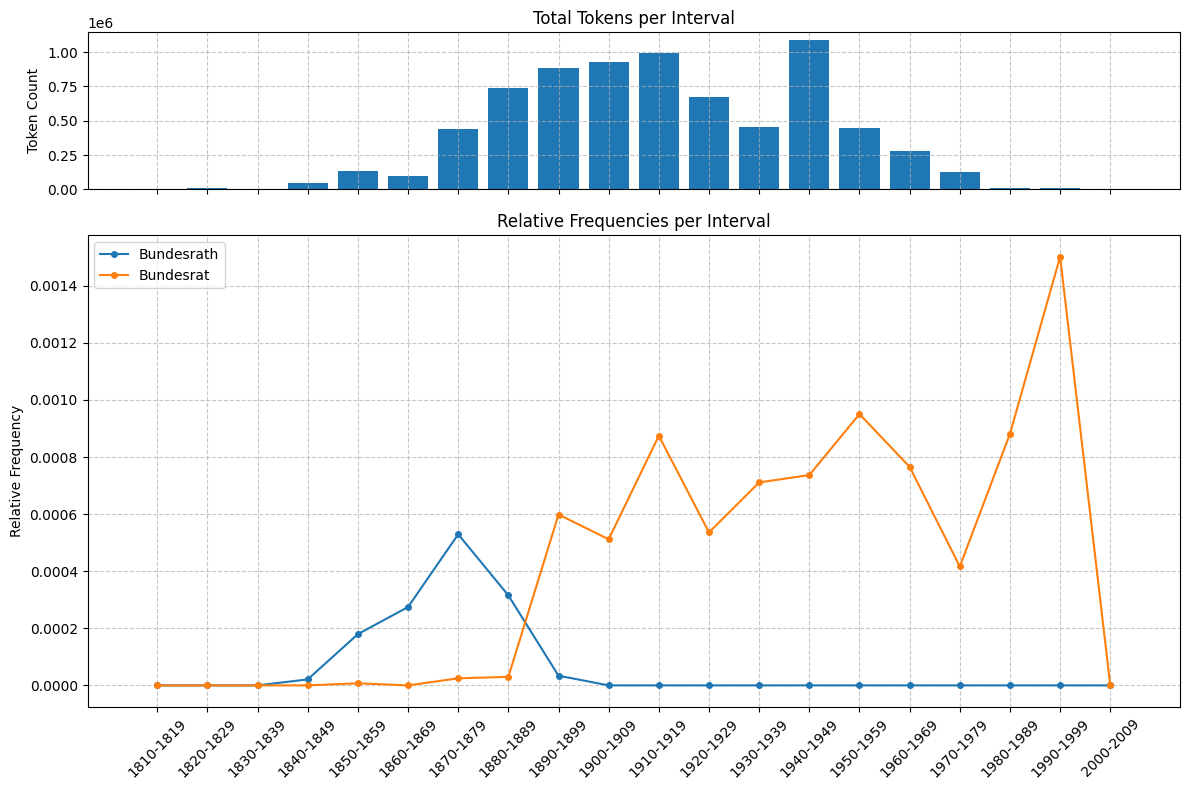

In [124]:
fa_diachron.plot_frequencies(["Bundesrath", "Bundesrat"], freqtype="relative")

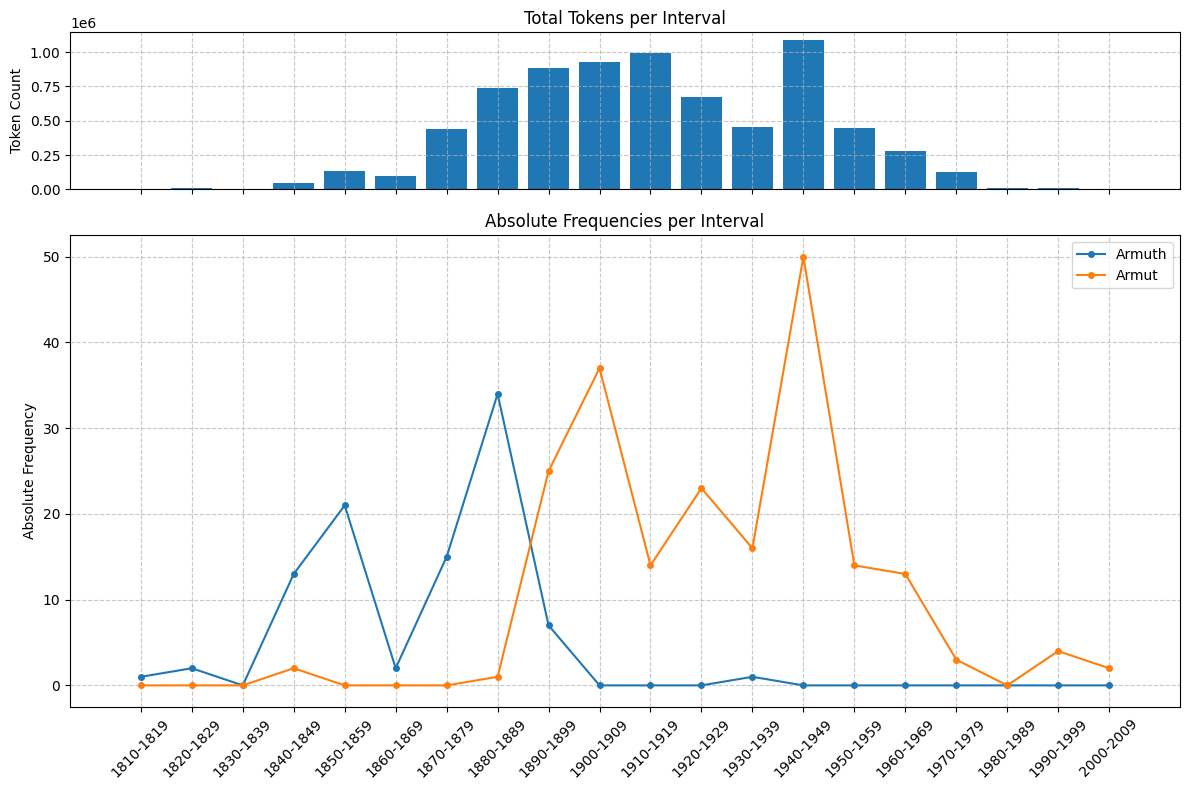

In [125]:
# ⬇️⬇️⬇️ Try other search terms
SEARCH_TERMS = ["Armuth", "Armut"]
FREQUENCY_TYPE = "absolute" # Choose between "absolute", "relative", and "normalized"
# ⬆️⬆️⬆️

fa_diachron.plot_frequencies(SEARCH_TERMS, freqtype=FREQUENCY_TYPE)

## Collocation Analyses

### Collocation code

In [ ]:
import math
from collections import Counter
from functools import lru_cache
from typing import Iterable, Literal

SMALL = 1/2

class CollocationEngine:
    def __init__(self, df: pd.DataFrame, column: Literal["lemmas", "tokens"], window: int = 5, stopwords: Iterable[str] = []):
        self.df = df.copy()
        self.column = column
        self.window = window
        self.stopwords = stopwords

        self.token_counts = count_tokens(self.df, column=self.column)

        stopword_count = sum(count for token, count in self.token_counts.items() if token in self.stopwords)
        for stopword in self.stopwords:
            self.token_counts.pop(stopword, None)
        self.token_counts["<STOPWORD>"] = stopword_count

        self.total_tokens = sum(self.token_counts.values())

    def calc_llr(self, data):
        llr_value = 0.0
        for node_presence in ["n", "xn"]:
            for collocate_presence in ["c", "xc"]:
                o = data[f"o_{node_presence}_{collocate_presence}"]
                e = data[f"e_{node_presence}_{collocate_presence}"]
                if o > 0 and e > 0:
                    llr_value += o * math.log(o / e)
        return llr_value * 2

    def calc_lr(self, data):
        logprob_n = math.log((data["o_n_c"] + SMALL) / (data["o_n"] + SMALL))  # Add-one smoothing
        logprob_xn = math.log((data["o_xn_c"] + SMALL) / (data["o_xn"] + SMALL))  # Add-one smoothing
        return logprob_n - logprob_xn

    def calc_mi(self, data):
        return math.log((data["o_n_c"] + SMALL) / (data["e_n_c"] + SMALL))  # Add-one smoothing

    def get_collocations_for_word(
        self,
        node: str | Iterable[str],
        metric: Literal["llr", "lr", "mi"] = "llr",
    ) -> pd.DataFrame:
        if isinstance(node, str):
            normalized_nodes = (node,)
        else:
            normalized_nodes = tuple(node)

        if len(normalized_nodes) == 0:
            return pd.DataFrame()

        scored_df = self._score_collocation_counts(normalized_nodes, metric)

        return self._reformat_df_for_user(scored_df, metric)

    def _reformat_df_for_user(self, df: pd.DataFrame, metric: Literal["llr", "lr", "mi"]) -> pd.DataFrame:
        if df.empty:
            return df.copy()

        user_df = df[[
            "collocate",
            "o_n_c",
            "o_n_xc",
            "o_xn_c",
            "o_c",
            "o_n",            
            "metric",

        ]].copy()
        user_df = user_df.rename(columns={
            "o_n_c": "Node with Collocate",
            "o_n_xc": "Node without Collocate",
            "o_xn_c": "Collocate without Node",
            "o_c": "Collocate Count",
            "o_n": "Node Count",
            "metric": metric,
        })
        return user_df

    def _score_collocation_counts(
        self,
        node: tuple[str, ...],
        metric: Literal["llr", "lr", "mi"],
    ) -> pd.DataFrame:
        colloc_df = self._get_collocation_counts_cached(node)
        if colloc_df.empty:
            return colloc_df.copy()

        scored_df = colloc_df.copy()
        if metric == "llr":
            scored_df["metric"] = scored_df.apply(self.calc_llr, axis=1)
        elif metric == "lr":
            scored_df["metric"] = scored_df.apply(self.calc_lr, axis=1)
        elif metric == "mi":
            scored_df["metric"] = scored_df.apply(self.calc_mi, axis=1)
        else:
            raise ValueError(f"Unknown metric: {metric}")

        scored_df = scored_df.sort_values(by="metric", ascending=False)
        return scored_df

    @lru_cache(maxsize=128)
    def _get_collocation_counts_cached(self, node: tuple[str, ...]) -> pd.DataFrame:
        collocation_df = pd.DataFrame(columns=[
            "collocate",
            "o_n",
            "o_xn",
            "o_c",
            "o_n_c",
            "o_n_xc",
            "o_xn_c",
            "o_xn_xc",
            "e_n_c",
            "e_n_xc",
            "e_xn_c",
            "e_xn_xc",
        ])

        o_n = sum(self.token_counts.get(n, 0) for n in node)
        if o_n == 0:
            print(f"⚠️ The word '{node}' does not appear in the corpus. No collocations to compute.")
            return collocation_df

        if any(n in self.stopwords for n in node):
            print(f"⚠️ The word '{node}' is a stopword. Consider setting mask_stopwords=False to include it in collocation counts.")
            return collocation_df

        collocation_counts = Counter()

        for doc in tqdm(self.df[self.column], desc=f"Counting collocations for '{node}'", leave=False):
            full_text = [token for sentence in doc for token in sentence]
            if self.stopwords:
                full_text = [token if token not in self.stopwords else "<STOPWORD>" for token in full_text]
            for i, token in enumerate(full_text):
                if token in node:
                    start = max(i - self.window, 0)
                    end = min(i + self.window + 1, len(full_text))
                    collocates = full_text[start:i] + full_text[i + 1:end]
                    collocates = set(collocates)  # Avoid overcounting the same collocate multiple times in the same window
                    collocation_counts.update(collocates)

        rows = []
        for collocate, o_n_c in collocation_counts.items():
            o_c = self.token_counts.get(collocate, 0)

            if o_n_c > o_c:
                o_n_c = o_c

            o_n_xc = o_n - o_n_c
            o_xn_c = o_c - o_n_c
            o_xn_xc = self.total_tokens - (o_n + o_c - o_n_c)
            o_xn = self.total_tokens - o_n

            e_n_c = (o_n * o_c) / self.total_tokens
            e_n_xc = (o_n * (self.total_tokens - o_c)) / self.total_tokens
            e_xn_c = ((self.total_tokens - o_n) * o_c) / self.total_tokens
            e_xn_xc = ((self.total_tokens - o_n) * (self.total_tokens - o_c)) / self.total_tokens

            rows.append({
                "collocate": collocate,
                "o_n_c": o_n_c,
                "o_n_xc": o_n_xc,
                "o_xn_c": o_xn_c,
                "o_xn_xc": o_xn_xc,
                "o_n": o_n,
                "o_xn": o_xn,
                "o_c": o_c,
                "e_n_c": e_n_c,
                "e_n_xc": e_n_xc,
                "e_xn_c": e_xn_c,
                "e_xn_xc": e_xn_xc,
            })

        colloc_df = pd.concat([collocation_df, pd.DataFrame(rows)], ignore_index=True)
        return colloc_df


### Analyses

In [82]:
STOPWORDS = set(nltk.corpus.stopwords.words("german"))

# ⬇️⬇️⬇️ Adjust the stopword list if you find other undesired characters or words in your analyses.
# ❗ Stopword removal is unelegant but necessary for certain collocation metrics.
# Take caution, as you are altering and biasing your object of study.
STOPWORDS = STOPWORDS.union(set([
    "»", 
    "«", 
    ".", 
    ",",
]))
# ⬆️⬆️⬆️

colloc_engine = CollocationEngine(raw_df, "lemmas", window=5, stopwords=list(STOPWORDS))

Counting Tokens:   0%|          | 0/2633 [00:00<?, ?it/s]

In [89]:
# ⬇️⬇️⬇️ Adjust the query here to find collocates for other words or with other metrics.
colloc_engine.get_collocations_for_word("Armut", metric="llr")
# ⬆️⬆️⬆️

,collocate,llr,Node without Collocate,Collocate without Node,Collocate Count,Node Count
2,<STOPWORD>,304.160329,0,3502700,3502904,204
144,Ursache,295.026558,181,521,544,204
70,Not,116.898101,193,737,748,204
136,Elend,97.138849,196,247,255,204
8,Familie,84.397931,193,3267,3278,204
...,...,...,...,...,...,...
460,(,1.546991,202,25929,25931,204
284,Le,1.244756,203,9233,9234,204
438,neu,1.173760,203,9687,9688,204
547,Art,1.170737,203,9707,9708,204


In [87]:
# ⬇️⬇️⬇️ You can combine spellings or inflectional variants in the query to get more robust results.
colloc_engine.get_collocations_for_word(["Armut", "Armuth"], metric="mi")
# ⬆️⬆️⬆️

,collocate,mi,Node without Collocate,Collocate without Node,Collocate Count,Node Count
157,Ursache,3.806883,277,521,544,300
79,Not,3.076475,289,737,748,300
70,groß,3.068796,281,9979,9998,300
149,Elend,3.024009,290,245,255,300
107,Bekämpfung,2.902264,291,521,530,300
...,...,...,...,...,...,...
373,2,0.636727,299,7222,7223,300
724,Zürich,0.622641,299,7499,7500,300
423,Le,0.538705,299,9233,9234,300
660,Kanton,0.406873,299,12268,12269,300


### Compare collocations across different time slices

#### Code for collocation comparison class

In [104]:
class CollocationComparer:
    def __init__(self, dfs: dict[str, pd.DataFrame], column: Literal["lemmas", "tokens"], window: int = 5, stopwords: Iterable[str] = []):
        self.dfs = dfs
        self.column = column
        self.window = window
        self.stopwords = stopwords

        self.engines = {
            name: CollocationEngine(df, column=column, window=window, stopwords=stopwords)
            for name, df in dfs.items()
        }

    def compare_collocations_for_word(self, node: str | list[str], metric: Literal["llr", "lr", "mi"] = "llr") -> pd.DataFrame:
        colloc_dfs = {}
        for name, engine in self.engines.items():
            colloc_dfs[name] = engine.get_collocations_for_word(node, metric=metric)

        col_names = []
        col_names.append("Rank")
        for name in self.dfs.keys():
            col_names.append(f"{name}_collocate")
            col_names.append(f"{name}_{metric}")
        
        comparison_df = pd.DataFrame()

        for name, colloc_df in colloc_dfs.items():
            colloc_df = colloc_df.sort_values(by=metric, ascending=False).head(20)
            colloc_df = colloc_df.reset_index(drop=True)
            colloc_df = colloc_df[["collocate", "Node with Collocate"]]
            colloc_df.columns = [f"{name}_collocate", f"{name}_#"]
            comparison_df = pd.concat([comparison_df, colloc_df], axis=1)

        return comparison_df

#### Analyses

In [ ]:
# ⬇️⬇️⬇️ Define your own time intervals (or other filters) to compare different subsets of the corpus.
dfs = {
    "pre1880": raw_df[raw_df["year"] < 1880],
    "1880-1900": raw_df[(raw_df["year"] >= 1880) & (raw_df["year"] < 1900)],
    "1900-1920": raw_df[(raw_df["year"] >= 1900) & (raw_df["year"] < 1920)],
    "post1920": raw_df[raw_df["year"] >= 1920],
}

comparer = CollocationComparer(dfs, column="lemmas", window=5, stopwords=STOPWORDS)
# ⬆️⬆️⬆️

In [136]:
# ⬇️⬇️⬇️ Adjust the node(s) and metric to compare collocates across the defined subsets.
NODES = ["Armenpflege"]
METRIC = "llr" # Choose between "llr", "lr", and "mi"
# ⬆️⬆️⬆️

comparer.compare_collocations_for_word(NODES, metric=METRIC)

,pre1880_collocate,pre1880_#,1880-1900_collocate,1880-1900_#,1900-1920_collocate,1900-1920_#,post1920_collocate,post1920_#
0,<STOPWORD>,390,<STOPWORD>,654,<STOPWORD>,844,<STOPWORD>,1563
1,freiwillig,46,freiwillig,58,freiwillig,49,öffentlich,86
2,gesetzlich,17,bürgerlich,39,öffentlich,42,Mitglied,53
3,bürgerlich,14,öffentlich,45,bürgerlich,27,müssen,60
4,öffentlich,16,örtlich,29,Last,22,Last,32
5,frei,13,staatlich,22,interkantonale,16,unterstützt,30
6,örtlich,6,System,17,interkantonalen,13,Schulrat,21
7,),21,bie,30,sollen,32,Fürsorge,34
8,Freiwilliger,5,Freiwilliger,9,Freiwilliger,13,Präsident,32
9,privat,5,kirchlich,12,Allgemeine,13,Interkantonale,13
